In [1]:
%load_ext autoreload
%autoreload 2

### Setup

In [2]:
import os, sys
sys.path.append(os.path.dirname(os.getcwd()))
from utils import DATA_DIR, ROOT_DIR

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from dataloader import get_nd_array, get_slice
from download.hf import pull_predictions_from_hf

# Import scaling law code
sys.path.append(os.path.join(f'{ROOT_DIR}/olmo-repos/olmo/scripts'))
sys.path.append(os.path.join(f'{ROOT_DIR}/olmo-repos/olmo/scripts/scaling'))
import ladder
plt.close()

In [3]:
# Change how dataframes are displayed
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 3) 

### Pull benchmark results

In [4]:
# Download benchmark-level results from Huggingface
local_path = pull_predictions_from_hf("allenai/ladder-evals", "benchmarks")

In [5]:
# Load benchmark evaluations
df = pd.read_parquet(local_path)
print(f'Loaded {len(df):,} model evaluations')

Loaded 95,475 model evaluations


In [6]:
MODELS = sorted(list(df['model'].unique()))         # base model name
MIXES  = sorted(list(df['mix'].dropna().unique()))  # data mixes (if applicable)
STEPS  = sorted(list(df['step'].unique()))          # training steps (if applicable)
TASKS  = sorted(list(df['task'].unique()))          # task name

print('Here are the list of models we have:')
print(MODELS)

Here are the list of models we have:
['DCLM-baseline-1B-5xC', 'Llama-2-13b-hf', 'Llama-2-7b-hf', 'Llama-3.2-1B', 'Llama-3.2-3B', 'Meta-Llama-3-70B', 'Meta-Llama-3-8B', 'Meta-Llama-3.1-70B', 'Meta-Llama-3.1-8B', 'Mistral-7B-v0.1', 'Mistral-7B-v0.3', 'OLMo-1B-0724-hf', 'OLMo-1B-hf', 'OLMo-7B-0424-hf', 'OLMo-7B-0724-hf', 'OLMo-7B-hf', 'OLMoE-1B-7B-0924', 'Qwen2-1.5B', 'Qwen2-7B', 'Qwen2.5-14B', 'Qwen2.5-32B', 'Qwen2.5-3B', 'Qwen2.5-72B', 'Qwen2.5-7B', 'baseline-1B-5xC', 'c4-1B-5xC', 'deepseek-llm-7b-base', 'dolma-v1-6-and-sources-baseline-1B-5xC', 'dolma17-25p-DCLM-baseline-75p-1B-5xC', 'dolma17-50p-DCLM-baseline-50p-1B-5xC', 'dolma17-75p-DCLM-baseline-25p-1B-5xC', 'falcon-1B-5xC', 'falcon-7b', 'falcon_and_cc-1B-5xC', 'falcon_and_cc_eli5_oh_top10p-1B-5xC', 'falcon_and_cc_eli5_oh_top20p-1B-5xC', 'falcon_and_cc_og_eli5_oh_top10p-1B-5xC', 'falcon_and_cc_tulu_qc_top10-1B-5xC', 'fineweb_edu_dedup-1B-5xC', 'gemma-2-2b', 'gemma-2-9b', 'gemma-2b', 'gemma-7b', 'mpt-7b', 'neo_7b', 'no_code-1B-5xC',

In [7]:
# Get a dataframe of results
slice = get_slice(df, task='gsm8k')

print('Here are all the GSM results:')
display(slice)

# You can specify multiple tasks to pull from
slice = get_slice(df, task=['gsm8k', 'gsm8k:perturb_cot'])

print('Here are all the GSM and GSM (distractor chain-of-thought version) results:')
display(slice)

# You can specify multiple tasks to pull from
slice = get_slice(df, model='Meta-Llama-3.1-8B')

print('Here are all the Llama 3.1 8B results:')
display(slice)

# You can specify any number of lists of constraints for {mix, model, task, step}
slice = get_slice(df, mix='no_reddit', model='no_reddit-1B-5xC', task=['arc_challenge', 'arc_easy'], step='max')

print('Here are the results from 4 contraints:')
display(slice)

Here are all the GSM results:


,index,Unnamed: 0,task_name,task_hash,model_hash,model_config,processing_time,current_date,num_instances,metrics,task_idx,acc_raw,acc_per_token,acc_per_char,acc_uncond,primary_score,logits_per_byte_corr,logits_per_char_corr,model,mix,step,size,token_ratio,step_str,task,s3_path,exact_match_simple,exact_match,extra_metrics,f1,bits_per_byte,ppl_token,ppl_char,ppl_word,ppl_byte,exact_match_flex,pass_at_1,recall,exact_match_sub_mctest,exact_match_sub_race,exact_match_sub_cnn,exact_match_sub_wikipedia,exact_match_sub_gutenberg,f1_sub_mctest,f1_sub_race,f1_sub_cnn,f1_sub_wikipedia,f1_sub_gutenberg,pass_at_10
0,13,13,gsm8k,7ad2a4339c66f71b671d15c6138b11da,bb12600a40f8f69f2f9acc8aec836606,"{'revision': None, 'trust_remote_code': None, ...",203.624790,2024-12-20 11:27:52 UTC,1319,"{'exact_match_simple': 0.29567854435178165, 'e...",0,1.0,1.0,1.0,NaN,0.295679,0.333590,-0.231434,OLMo-7B-0724-hf,None,NaN,None,None,None,gsm8k,/oe-eval-default/davidh/metaeval/analysis/data...,0.295679,0.295679,{'num_tokens': 74.37604245640637},NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
243,95261,95261,gsm8k,7ad2a4339c66f71b671d15c6138b11da,bae85a86ec8c8533fdb81533db3f039b,"{'revision': None, 'trust_remote_code': None, ...",80.232089,2024-12-20 10:34:57 UTC,1319,"{'exact_match_simple': 0.02047005307050796, 'e...",0,1.0,1.0,1.0,NaN,0.020470,0.725837,-0.503570,peteish-moreeval-1B-5xC,peteish-ladder,15000.0,1B,5xC,step15000-unsharded-hf,gsm8k,/oe-eval-default/davidh/metaeval/analysis/data...,0.020470,0.020470,{'num_tokens': 85.44882486732374},NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Here are all the GSM and GSM (distractor chain-of-thought version) results:


,index,Unnamed: 0,task_name,task_hash,model_hash,model_config,processing_time,current_date,num_instances,metrics,task_idx,acc_raw,acc_per_token,acc_per_char,acc_uncond,primary_score,logits_per_byte_corr,logits_per_char_corr,model,mix,step,size,token_ratio,step_str,task,s3_path,exact_match_simple,exact_match,extra_metrics,f1,bits_per_byte,ppl_token,ppl_char,ppl_word,ppl_byte,exact_match_flex,pass_at_1,recall,exact_match_sub_mctest,exact_match_sub_race,exact_match_sub_cnn,exact_match_sub_wikipedia,exact_match_sub_gutenberg,f1_sub_mctest,f1_sub_race,f1_sub_cnn,f1_sub_wikipedia,f1_sub_gutenberg,pass_at_10
0,13,13,gsm8k,7ad2a4339c66f71b671d15c6138b11da,bb12600a40f8f69f2f9acc8aec836606,"{'revision': None, 'trust_remote_code': None, ...",203.624790,2024-12-20 11:27:52 UTC,1319,"{'exact_match_simple': 0.29567854435178165, 'e...",0,1.0,1.00,1.00,NaN,0.295679,0.333590,-0.231434,OLMo-7B-0724-hf,None,NaN,None,None,None,gsm8k,/oe-eval-default/davidh/metaeval/analysis/data...,0.295679,0.295679,{'num_tokens': 74.37604245640637},NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
487,95283,95283,gsm8k:perturb_cot,04ddec308dd3765552204dc1fa2b510a,c33a634a236e33d992084070e1663b17,"{'revision': None, 'trust_remote_code': None, ...",0.023333,2024-12-13 05:15:50 UTC,100,"{'acc_raw': 0.4, 'acc_per_token': 0.28, 'acc_p...",36,0.4,0.28,0.14,0.2,NaN,1.192706,-0.827833,peteish-moreeval-1B-5xC,peteish-ladder,15000.0,1B,5xC,step15000-unsharded-hf,gsm8k:perturb_cot,/oe-eval-default/davidh/metaeval/analysis/data...,NaN,NaN,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Here are all the Llama 3.1 8B results:


,index,Unnamed: 0,task_name,task_hash,model_hash,model_config,processing_time,current_date,num_instances,metrics,task_idx,acc_raw,acc_per_token,acc_per_char,acc_uncond,primary_score,logits_per_byte_corr,logits_per_char_corr,model,mix,step,size,token_ratio,step_str,task,s3_path,exact_match_simple,exact_match,extra_metrics,f1,bits_per_byte,ppl_token,ppl_char,ppl_word,ppl_byte,exact_match_flex,pass_at_1,recall,exact_match_sub_mctest,exact_match_sub_race,exact_match_sub_cnn,exact_match_sub_wikipedia,exact_match_sub_gutenberg,f1_sub_mctest,f1_sub_race,f1_sub_cnn,f1_sub_wikipedia,f1_sub_gutenberg,pass_at_10
0,1034,1034,mmlu_professional_psychology,e646e50900aacb07ab1cf1e08ffe1652,b760db055c53d037459feca23a4a02f6,"{'revision': None, 'trust_remote_code': None, ...",77.236878,2024-12-22 21:32:37 UTC,612,"{'acc_raw': 0.4493464052287582, 'acc_per_token...",50,0.449346,0.509804,0.508170,0.491830,0.508170,0.616858,-0.430132,Meta-Llama-3.1-8B,None,NaN,None,None,None,mmlu_professional_psychology,/oe-eval-default/davidh/metaeval/analysis/data...,NaN,NaN,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
391,1425,1425,mmlu_nutrition,d72257295d235066a186a594f722f564,b760db055c53d037459feca23a4a02f6,"{'revision': None, 'trust_remote_code': None, ...",36.111797,2024-12-22 21:15:49 UTC,306,"{'acc_raw': 0.39215686274509803, 'acc_per_toke...",44,0.392157,0.503268,0.473856,0.457516,0.473856,0.622211,-0.431459,Meta-Llama-3.1-8B,None,NaN,None,None,None,mmlu_nutrition,/oe-eval-default/davidh/metaeval/analysis/data...,NaN,NaN,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Here are the results from 4 contraints:


,index,Unnamed: 0,task_name,task_hash,model_hash,model_config,processing_time,current_date,num_instances,metrics,task_idx,acc_raw,acc_per_token,acc_per_char,acc_uncond,primary_score,logits_per_byte_corr,logits_per_char_corr,model,mix,step,size,token_ratio,step_str,task,s3_path,exact_match_simple,exact_match,extra_metrics,f1,bits_per_byte,ppl_token,ppl_char,ppl_word,ppl_byte,exact_match_flex,pass_at_1,recall,exact_match_sub_mctest,exact_match_sub_race,exact_match_sub_cnn,exact_match_sub_wikipedia,exact_match_sub_gutenberg,f1_sub_mctest,f1_sub_race,f1_sub_cnn,f1_sub_wikipedia,f1_sub_gutenberg,pass_at_10
0,43366,43366,arc_challenge,d6fe6f843c671beee66037f10323519d,30d33b3f7e0784462755b2091c807a44,"{'revision': None, 'trust_remote_code': None, ...",133.478979,2024-12-22 08:45:58 UTC,1172,"{'acc_raw': 0.3054607508532423, 'acc_per_token...",0,0.305461,0.335324,0.331911,0.383106,0.383106,1.234421,-0.857037,no_reddit-1B-5xC,no_reddit,69369.0,1B,5xC,step69369-unsharded-hf,arc_challenge,/oe-eval-default/davidh/metaeval/analysis/data...,NaN,NaN,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,43499,43499,arc_easy,ccfce00c49ea5f98347e8fffc3682eda,30d33b3f7e0784462755b2091c807a44,"{'revision': None, 'trust_remote_code': None, ...",233.586562,2024-12-22 08:48:12 UTC,2376,"{'acc_raw': 0.6355218855218855, 'acc_per_token...",1,0.635522,0.566919,0.589646,0.580808,0.589646,1.202191,-0.833932,no_reddit-1B-5xC,no_reddit,69369.0,1B,5xC,step69369-unsharded-hf,arc_easy,/oe-eval-default/davidh/metaeval/analysis/data...,NaN,NaN,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
step_names, scores = get_nd_array(
    df,
    col=["step"], # the dimensions of the array
    metric="primary_score", # the entries of the array
    model="peteish-moreeval-1B-5xC",
    task="arc_challenge",
    mix=None,
    step=None,
    sorted=True
)

print(f'Results on {len(step_names)} intermediate checkpoints of OLMo 1B 5xC (first 20, sorted by performance):')
print(step_names[:20])
print(scores[:20])
print(scores.shape)

Results on 164 intermediate checkpoints of OLMo 1B 5xC (first 20, sorted by performance):
[500.0, 0.0, 1000.0, 1500.0, 3000.0, 2000.0, 4000.0, 4500.0, 2500.0, 3500.0, 5000.0, 7000.0, 9500.0, 9000.0, 6500.0, 6000.0, 10000.0, 8500.0, 12500.0, 14500.0]
[0.24488055 0.24914676 0.25682594 0.26109215 0.26450512 0.27474403
 0.28498294 0.29522184 0.29522184 0.30204778 0.30290102 0.30546075
 0.30716724 0.31740614 0.31740614 0.32167235 0.32337884 0.32764505
 0.32849829 0.32849829]
(164,)


In [9]:
model_names, scores = get_nd_array(
    df,
    col=["model"], # the dimensions of the array
    metric="primary_score", # the entries of the array
    task="arc_challenge",
    model=None,
    mix=None,
    step=None,
    sorted=True
)

print(f'Results on {len(model_names)} models (first 20):')
print(model_names[:20])
print(scores[:20])
print(scores.shape)

Results on 245 models (first 20):
['redpajama-1B-5xC', 'peteish-moreeval-1B-5xC', 'peteish-moreeval-1B-5xC', 'peteish-moreeval-190M-0.5xC', 'peteish-moreeval-rerun-190M-1xC', 'peteish-moreeval-1B-5xC', 'pythia-160m', 'peteish-moreeval-190M-2xC', 'peteish-moreeval-1B-5xC', 'peteish-moreeval-1B-5xC', 'peteish-moreeval-1B-5xC', 'peteish-moreeval-190M-5xC', 'peteish-moreeval-370M-0.5xC', 'peteish-moreeval-1B-5xC', 'peteish-moreeval-rerun-370M-1xC', 'peteish-moreeval-370M-2xC', 'peteish-moreeval-1B-5xC', 'peteish-moreeval-1B-5xC', 'peteish-moreeval-760M-0.5xC', 'peteish-moreeval-1B-5xC']
[0.23549488 0.24488055 0.24914676 0.25426621 0.25511945 0.25682594
 0.25938567 0.26109215 0.26109215 0.26450512 0.27474403 0.27474403
 0.28156997 0.28498294 0.28498294 0.2883959  0.29522184 0.29522184
 0.29863481 0.30204778]
(245,)


### Pull instance results

In [10]:
# Download benchmark-level results from Huggingface
local_path = pull_predictions_from_hf("allenai/ladder-evals", "instances")

In [11]:
# Choose a subset of columns to save on memory
COLS = ['step', 'model', 'task', 'mix', 'size', 'token_ratio', 'native_id']
COLS += ['acc_per_char', 'logits_per_byte', 'correct_choice', 'logits_per_char_corr', 'logits_per_byte_corr'] # accuracy benchmarks
COLS += ['exact_match', 'f1'] # generation benchmarks
COLS += ['pass_at_1', 'pass_at_10'] # code benchmarks

# Load instance-level evaluations
df = pd.read_parquet(local_path, columns=COLS)
print(f'Loaded {len(df):,} instance results')

Loaded 104,940,911 instance results


In [12]:
step_names, scores = get_nd_array(
    df,
    col=["step"], # the dimensions of the array
    metric="acc_per_char", # the entries of the array
    task="arc_challenge",
    model="peteish-moreeval-1B-5xC",
    mix=None,
    step=None,
    sorted=True
)

print(f'Results on {len(step_names)} intermediate checkpoints:')
print(scores[:20])
print(scores.shape)

Results on 164 intermediate checkpoints:
[[0. 0. 0. ... 1. 0. 1.]
 [1. 0. 0. ... 1. 0. 1.]
 [1. 1. 0. ... 1. 0. 1.]
 ...
 [1. 0. 0. ... 1. 0. 1.]
 [1. 0. 0. ... 1. 0. 1.]
 [1. 0. 0. ... 1. 0. 1.]]
(164, 1172)


In [ ]:
step_names, scores = get_nd_array(
    df,
    col=["model"], # the dimensions of the array
    metric="logits_per_byte_corr", # the entries of the array
    task="hellaswag",
    model=['Meta-Llama-3-70B', 'Meta-Llama-3-8B', 'Meta-Llama-3.1-70B', 'Meta-Llama-3.1-8B'],
    mix=None,
    step=None,
    sorted=True
)

print(f'Results on {len(step_names)} models:')
print(scores)
print(scores.shape)

Results on 4 models:
[[0.65588518 0.6116348  0.54956071 ... 0.48028892 0.81955031 0.89153316]
 [0.65672094 0.62320221 0.57115823 ... 0.48196398 0.80954776 0.87056317]
 [0.61578158 0.63162423 0.48562889 ... 0.42486376 0.81062194 0.82005243]
 [0.62508694 0.62295345 0.49328594 ... 0.41864117 0.8175052  0.81879739]]
(4, 9570)


### Data on All Models

In [48]:
all_ladder_models   = [model for model in MODELS if 'peteish-moreeval' in model]
data_mixes          = [model for model in MODELS if '1B-5xC' in model if 'peteish' not in model]
all_models   = sorted([model for model in MODELS if model not in data_mixes + all_ladder_models])

In [49]:
model_names, scores = get_nd_array(
    df,
    col=["model"], # the dimensions of the array
    metric="acc_per_char", # the entries of the array
    task="hellaswag",
    model=all_models,
    sorted=True
)

print(f'Results on {len(model_names)} models:')
print(scores)
print(scores.shape)

Results on 37 models:
[[1. 1. 1. ... 1. 1. 1.]
 [1. 1. 1. ... 1. 1. 1.]
 [1. 1. 1. ... 1. 1. 1.]
 ...
 [1. 0. 1. ... 1. 1. 0.]
 [1. 0. 1. ... 1. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]
(37, 9570)


### Tools

Relative error of predicting 7B performance: 0.1265


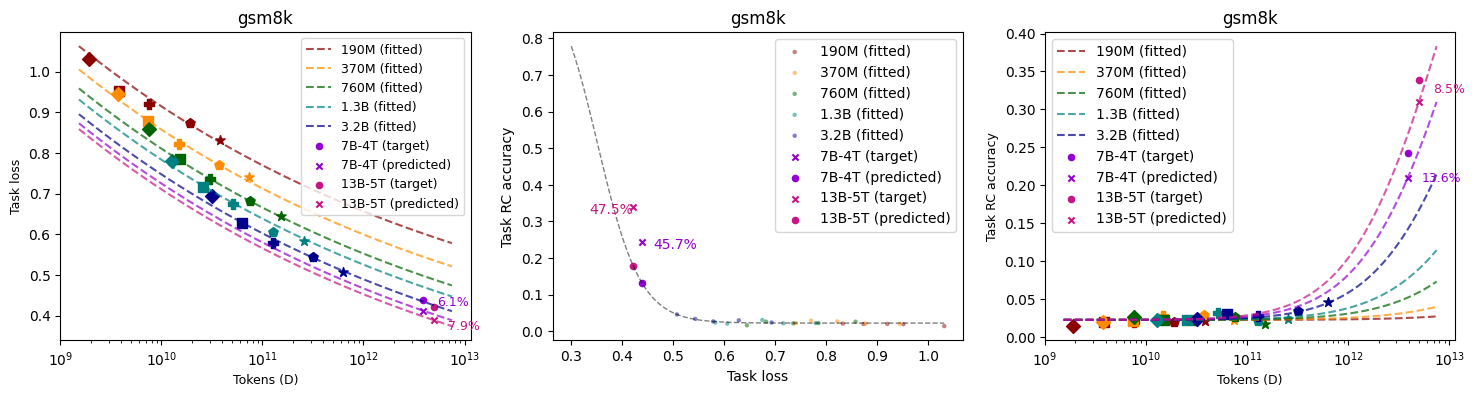

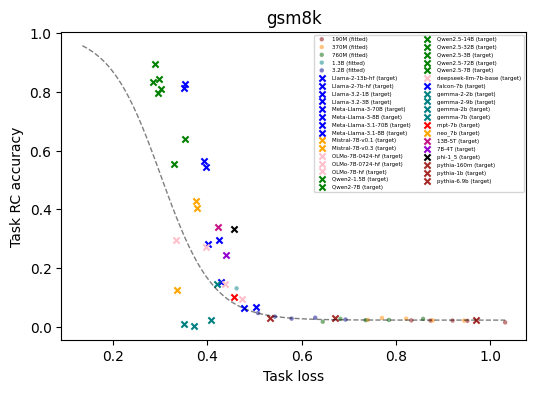

In [47]:
from ladder import run_ladder, sort_experiment_names

fig, axes = plt.subplots(1, 3, figsize=(6*3, 4), squeeze=False)

all_ladder_models = sort_experiment_names(all_ladder_models)
ladder_config_path = f'{ROOT_DIR}/analysis/utils/ladder_config.json'
task_name = "gsm8k"

# Run the ladder
_, _, rel_error = run_ladder(
    df,
    task_name,
    train_models=all_ladder_models,
    eval_models=["peteish7", "peteish13-highlr"],
    config_path=ladder_config_path,
    axes=axes[0],
)
print(f'Relative error of predicting 7B performance: {rel_error:.4f}')
plt.show()

fig, axes = plt.subplots(1, 1, figsize=(6, 4), squeeze=False)

# Run the ladder with external models
_, _, _ = run_ladder(
    df,
    task_name,
    train_models=all_ladder_models,
    eval_models=all_models,
    config_path=ladder_config_path,
    axes=[axes[0, 0]],
    run_step1=False, run_stacked=False
)
axes[0, 0].legend(fontsize=4, ncols=2)
plt.show()

Computing pairwise comparisons: 100%|██████████| 1/1 [00:00<00:00,  1.45it/s]


p-values between model comparisons:
[[  nan 0.065 0.025 0.027 0.002 0.001 0.    0.   ]
 [  nan   nan 0.348 0.314 0.124 0.023 0.012 0.   ]
 [  nan   nan   nan 0.471 0.212 0.049 0.028 0.001]
 [  nan   nan   nan   nan 0.263 0.075 0.046 0.005]
 [  nan   nan   nan   nan   nan 0.243 0.156 0.017]
 [  nan   nan   nan   nan   nan   nan 0.406 0.092]
 [  nan   nan   nan   nan   nan   nan   nan 0.153]
 [  nan   nan   nan   nan   nan   nan   nan   nan]]


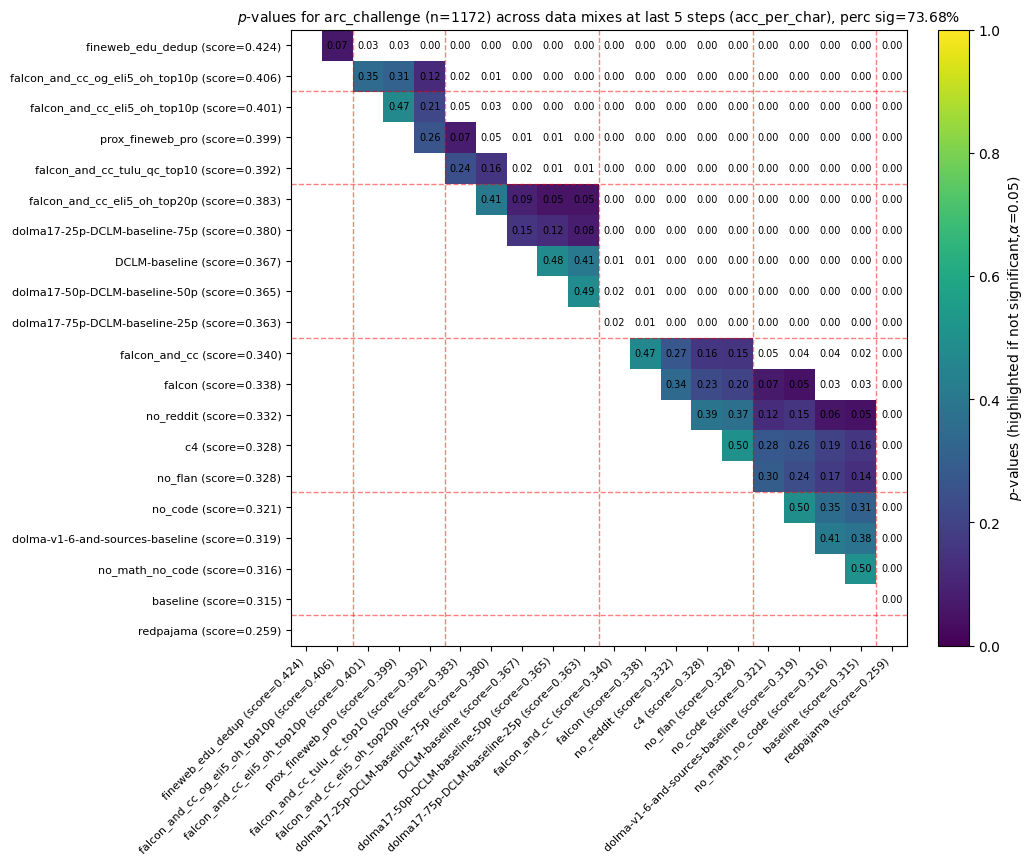

In [ ]:
from stats import compute_significance

task = 'arc_challenge'

# Run pairwise significance test between models
_, results, _ = compute_significance(
    df, 
    models=data_mixes, 
    metric='acc_per_char', 
    last_n=5,     # the "last n" checkpoints to average results
    alpha=0.05,   # significance level
    tasks=[task],
    do_plot=True
)
mixes, scores, p_values = results[task]

print(f'p-values between model comparisons:\n{p_values[:8, :8]}')

Total variation of arc_challenge training curve: 0.6694


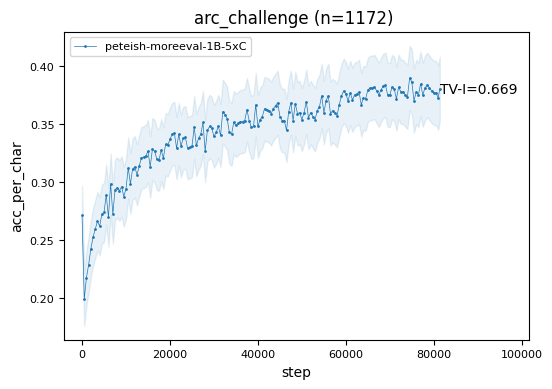

In [16]:
from stats import compute_total_variation

fig, axes = plt.subplots(1, 1, figsize=(6*1, 4), squeeze=False)

task = 'arc_challenge'

# Compute total variation across training checkpoints
tv_results, _ = compute_total_variation(
    df, 
    tasks=[task],
    models=['peteish-moreeval-1B-5xC'],
    metric='acc_per_char',
    axes=[axes[0][0]]
)
tv = tv_results[task]["total_variation"]
print(f'Total variation of {task} training curve: {tv:.4f}')